# Figure S4c – Combined scatter plot of B-factor correlations (all RMSD values)

Reads `data/processed/figure_4b_bfactors.csv` and saves `figures/figure_S4c.png`.


In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=1.0)

RMSD_PM = [0, 100, 200, 500, 1000, 1500, 2000]
RMSD_A  = [0,   1,   2,   5,   10,   15,   20]


In [3]:
df   = pd.read_csv(PROCESSED / 'figure_4b_bfactors.csv')
bf_0 = df['bfactor_0pm'].values


Saved figures/figure_S4c.png


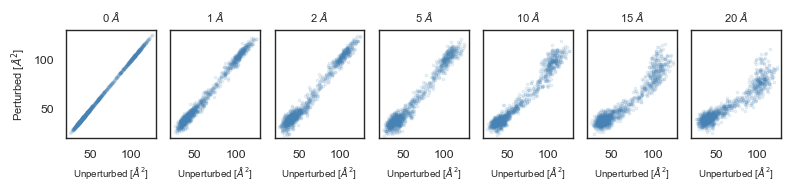

In [4]:
fig, axes = plt.subplots(1, len(RMSD_PM), figsize=(8 * len(RMSD_PM) / 7, 2), sharey=True)
for ax, rmsd_pm, rmsd_a in zip(axes, RMSD_PM, RMSD_A):
    bf = df[f'bfactor_{rmsd_pm}pm'].values
    ax.scatter(bf_0, bf, alpha=0.1, s=4, color='steelblue')
    ax.set_title(f'{rmsd_a} ' + r'$\AA$', fontsize=8)
    ax.set_xlim(20, 130)
    ax.set_ylim(20, 130)
    if ax == axes[0]:
        ax.set_ylabel(r'Perturbed [$\AA^{2}$]', fontsize=8)
    ax.set_xlabel(r'Unperturbed [$\AA^{2}$]', fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES / 'figure_S4c.png', dpi=300, bbox_inches='tight', format='pdf')
print('Saved figures/figure_S4c.png')
